### Lecture 15


### Practice Exercise - Solve the diffusion equation using the FTCS method

Practice coding the FTCS for the following diffusion problem. 

The flat base of a container made of a 1 cm thick stainless steel is initially at a uniform temperature of $20^\circ$ C everywhere. The container is placed in a bath of cold water at $0^\circ$ C and filled with hot water at $50^\circ$ C. 

Calculate the temperature profile of the steel as a function of distance $x$ from the hot side to the cold side, and as a function of time. For simplicity treat the base of the container as being arbitrarily wide, so that its temperature profile is the same everywhere, and assume that neither the hot nor the cold water changes temperature.

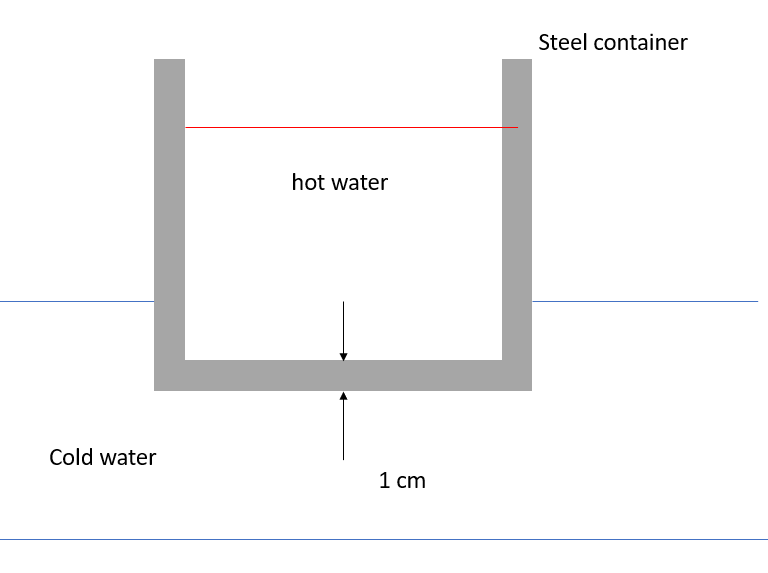

Thermal conduction is governed by the heat equation:

$$
\frac{\partial \phi}{dt} = D\frac{\partial ^2 \phi}{\partial x^2}
$$

where $D$ is the diffusion coefficient for steel, $4.25\times 10^{-6}$ m $^2$ s $^{-1}$. 

We have already derived the system of equations we need to solve above:

$$
\frac{d \phi_x}{dt} =  \frac{hD}{a^2}\left( \phi_{x+a} (t) + \phi_{x-a}(t) - 2\phi_x(t) \right)
$$


We can divide the $x$-dimension up into $M=100$ grid points, so we have a system of 98 equations to solve, since we solve only on the interior grid points. 

The initial condition specifies the temperature profile across the steel at time $0$:

$$
\phi(0,t=0) = 50^\circ C \qquad \text{top} 
$$

$$
\phi(M-1,t=0) = 0^\circ C \qquad \text{bottom} 
$$

$$
\phi(1:M-2,t=0) = 20^\circ C \qquad \text{everywhere else}
$$

The spatial boundary condition requires the temperatures at the top and bottom surfaces to be maintained constant over the time interval:


$$
\phi(0,t) = 50^\circ C \qquad \text{top} 
$$

$$
\phi(M-1,t) = 0^\circ C \qquad \text{bottom}
$$

or using Python array slicing notation:



$$
\phi(0,:) = 50^\circ C   
$$

$$
\phi(M-1,:) = 0^\circ C   
$$


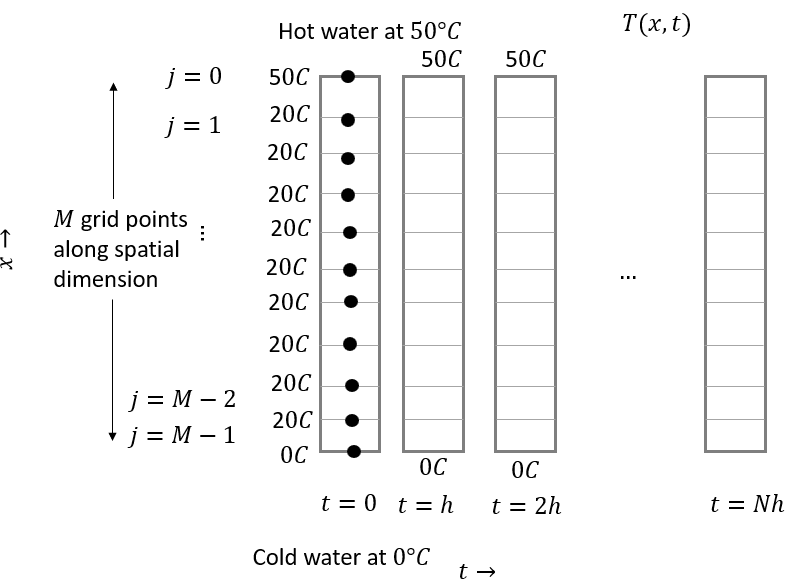

We solve the equations using Euler's method:

$$
\phi_x(t+h) = \phi_x(t) + \frac{hD}{a^2}\left( \phi_{x+a}(t) + \phi_{x-a}(t) - 2\phi_x(t) \right)
$$

Let's think about the pseudo-code.

1. Define the physical constants including the diffusion coeffient and thickness of container.
2. Define the size of the solution grid, that is $\phi(x,t)$. You will need to define the number of grid points along the $x$ and $t$-dimensions. For the purposes of this problem, choose $M=100$ space points, and $T=10000$ time points.
3. Create an $M\times N$ array to store the temperatures at each grid point.
4. Specify the initial and boundary conditions.
5. Define the time interval over which to calculate the solution, use 10 seconds. 
6. Calculate the size of each time step, *h*.
7. Calculate the distance between each grid point in the $x$-dimension. This is $a$.
8. For plotting purposes, create 1D arrays to hold the x-positions and times at each grid point.
9. Using a ```for```-loop, step through the time interval
    * For each time step, update the values of each $\phi_m$ using Euler's method. Only update the interior points.
10. Plot the temperature profile at the end of the time interval.

Note, convert temperatures to Kelvin. 

In [3]:
# Diffusion equation
# Practice solving initial value PDE using FTCS method
import numpy as np
import matplotlib.pyplot as plt

D = 4.25e-6 #m^2 s^{-1}
length_c = 0.01 # m
hot = 50 # C
cold = 0 # C 
mid_temp = 20 # C
M_points = 100
a = length_c/M_points

x_set = np.full(M_points, 20)
x_set[0] = hot
x_set[M_points -1] = cold

def dT(x_set, index):
    return D * (x_set[index + 1] + x_set[index - 1] + x_set[index])/a**2

def next_t(x_set):
    x_new = np.copy(x_set)
    
    for i in range(1, M_points -1):
        x_new[i] = dT(x_set, i)

def x_evolve(x_set, time_steps):

    x_evolve = [x_set]
    
    for i in range(time_steps):
        x_evolve.append(next_t(x_evolve))
    
    return np.array(x_evolve)

x_evolution = x_evolve(x_set, 1000)


    
    
    

IndexError: list index out of range

You should find as time progresses the heat signature penetrates into the steel until there is a constant temperature gradient across the steel. 